Dimensi awal: (60000, 784) → Setelah PCA: (60000, 154)


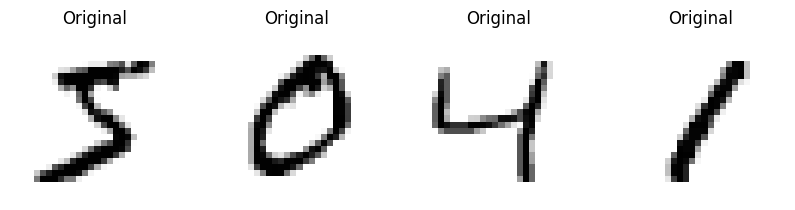

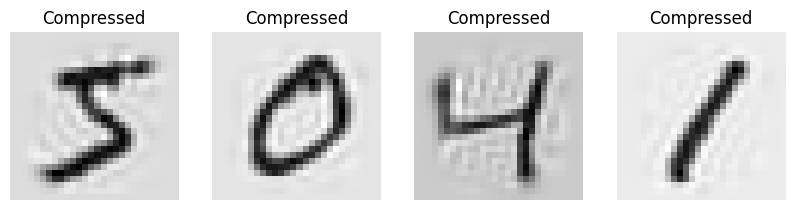

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, r

Best params (kPCA + Logistic): {'kpca__gamma': np.float64(0.03), 'kpca__kernel': 'rbf'}
RF accuracy tanpa PCA: 0.9705
RF accuracy dengan PCA: 0.9488


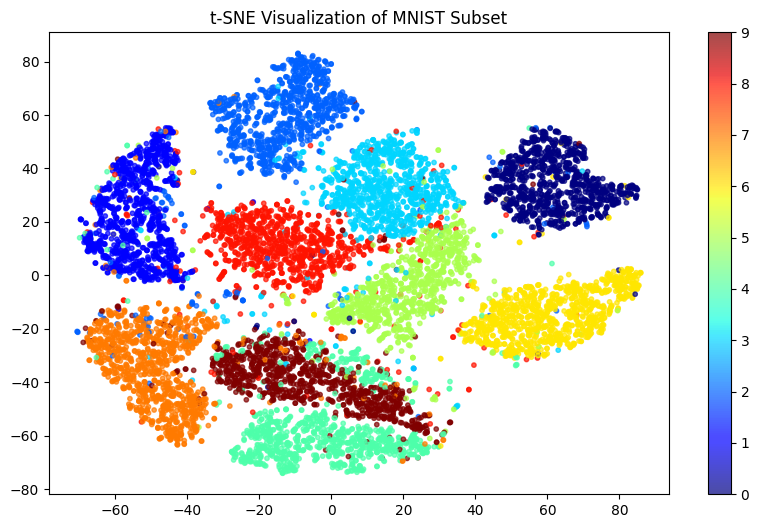

In [2]:
# ✅ Install library (opsional jika belum ada)
# !pip install scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error

##############################################
# 1️⃣ Dataset MNIST
##############################################
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

##############################################
# 2️⃣ PCA untuk Reduksi Dimensi
##############################################
pca = PCA(n_components=0.95)  # jaga 95% varian
X_reduced = pca.fit_transform(X_train)
print("Dimensi awal:", X_train.shape, "→ Setelah PCA:", X_reduced.shape)

##############################################
# 3️⃣ PCA untuk Kompresi & Dekompresi
##############################################
X_recovered = pca.inverse_transform(X_reduced)

##############################################
# 4️⃣ Visualisasi Kompresi MNIST
##############################################
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap="binary")
    ax.set_title("Original")
    ax.axis("off")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_recovered[i].reshape(28, 28), cmap="binary")
    ax.set_title("Compressed")
    ax.axis("off")
plt.show()

##############################################
# 5️⃣ Randomized PCA
##############################################
rnd_pca = PCA(n_components=154, svd_solver="randomized")
X_rnd_reduced = rnd_pca.fit_transform(X_train)

##############################################
# 6️⃣ Incremental PCA untuk Dataset Besar
##############################################
inc_pca = IncrementalPCA(n_components=154)
n_batches = 100
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)
X_inc_reduced = inc_pca.transform(X_train)

##############################################
# 7️⃣ Kernel PCA (Nonlinear Dimensionality Reduction)
##############################################
rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.04, fit_inverse_transform=True)
sample_idx = np.random.choice(len(X_train), 10000, replace=False)
X_small = X_train[sample_idx]
X_rbf_reduced = rbf_pca.fit_transform(X_small)
X_rbf_recovered = rbf_pca.inverse_transform(X_rbf_reduced)

##############################################
# 8️⃣ Grid Search untuk Kernel PCA + Logistic Regression
##############################################
clf = Pipeline([
    ("kpca", KernelPCA(n_components=2)),
    ("log_reg", LogisticRegression(max_iter=1000))
])

param_grid = [{
    "kpca__gamma": np.linspace(0.03, 0.05, 5),
    "kpca__kernel": ["rbf", "sigmoid"]
}]

grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_small, y_train[sample_idx])
print("Best params (kPCA + Logistic):", grid_search.best_params_)

##############################################
# 9️⃣ Locally Linear Embedding (LLE)
##############################################
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
X_lle_reduced = lle.fit_transform(X_small)

##############################################
# 🔟 Evaluasi RandomForestClassifier dengan dan tanpa PCA
##############################################
# Tanpa PCA
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("RF accuracy tanpa PCA:", accuracy_score(y_test, rf.predict(X_test)))

# Dengan PCA
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_reduced, y_train)
X_test_reduced = pca.transform(X_test)
print("RF accuracy dengan PCA:", accuracy_score(y_test, rf_pca.predict(X_test_reduced)))

##############################################
# 🔔 t-SNE untuk Visualisasi (opsional, lambat)
##############################################
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_small)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train[sample_idx], cmap="jet", s=10, alpha=0.7)
plt.colorbar()
plt.title("t-SNE Visualization of MNIST Subset")
plt.show()

# 📚 Chapter 8 - Dimensionality Reduction

---

## 🔸 1. Apa Itu Dimensionality Reduction?
**Dimensionality Reduction (Reduksi Dimensi)** adalah proses mengurangi jumlah fitur input dalam dataset sambil mempertahankan sebanyak mungkin informasi penting.

**Tujuan utama:**
- Mengurangi **overfitting**
- Mengurangi waktu komputasi
- Membantu visualisasi data (2D / 3D)

---

## 🔸 2. Principal Component Analysis (PCA)
PCA adalah teknik reduksi dimensi **linier** yang:
1. Mencari sumbu baru (**principal components**) → arah dengan variansi terbesar
2. Memproyeksikan data ke sumbu baru tersebut

**Persamaan PCA:**

\[
\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}
\]
- \(\mathbf{W}\): matrix principal components

**Varian yang Didukung:**
- `n_components=<jumlah/dimensi>` → tentukan dimensi target
- `n_components=0.95` → jaga 95% variansi asli
- `svd_solver="randomized"` → lebih cepat untuk dataset besar

---

## 🔸 3. Incremental PCA
- Digunakan untuk dataset **besar** → diproses dalam batch.
- Cocok jika data tidak muat di memori.

---

## 🔸 4. Kernel PCA
- Digunakan untuk **reduksi dimensi non-linear** dengan bantuan **kernel trick**.
- Mendukung berbagai kernel seperti:
  - `linear`
  - `poly`
  - `rbf`
  - `sigmoid`

**Hyperparameter penting:**
- `gamma` → pengaruh setiap data terhadap hasil transformasi.
- Bisa dikombinasikan dengan **GridSearchCV** untuk mencari parameter terbaik.

---

## 🔸 5. Locally Linear Embedding (LLE)
- Teknik non-linear berbasis manifold
- Preserves **local neighborhood** → cocok untuk data yang melengkung

---

## 🔸 6. t-SNE (t-Distributed Stochastic Neighbor Embedding)
- Teknik reduksi dimensi **khusus untuk visualisasi** data non-linear.
- Cocok untuk dataset kecil/menengah → lambat untuk dataset besar.
- Tidak cocok untuk **transformasi lanjutan/prediksi** → hanya untuk eksplorasi data.

---

## 🔸 7. Evaluasi Dimensionality Reduction
**Trade-off:**
- Lebih sedikit dimensi → lebih cepat & overfitting ↓
- Terlalu sedikit dimensi → **underfitting** → informasi hilang

---

## ✅ Kesimpulan
| Teknik           | Kapan Digunakan                     |
| ---------------- | ----------------------------------- |
| **PCA**          | Default untuk reduksi linier        |
| **Incremental PCA** | Dataset besar (tidak muat di RAM)  |
| **Kernel PCA**   | Reduksi non-linear + prediksi lanjut |
| **LLE**          | Data melengkung → reduksi untuk visualisasi/eksplorasi |
| **t-SNE**        | Visualisasi → eksplorasi data saja  |

